# 14 - Classical Modelling (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2
**Objective:** Train and evaluate Naive Bayes and Logistic Regression 
on genuine customer review data, establishing a realistic baseline 
ahead of DistilBERT fine-tuning in the next notebook.

## Import Libaries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.sparse import load_npz

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load the Dataset

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')

df = pd.read_csv(os.path.join(PROCESSED_PATH, 'production_preprocessed_reviews.csv'))
X = load_npz(os.path.join(PROCESSED_PATH, 'production_tfidf_matrix.npz'))

print(f"Dataframe loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"TF-IDF matrix loaded: {X.shape}")

Dataframe loaded: 21,055 rows x 11 columns
TF-IDF matrix loaded: (21055, 10000)


## Train, Validation, Test Split
Splitting the dataset 70/10/20, stratified by sentiment given the 
severe class imbalance identified in the quality assessment.

In [3]:
train_val_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.125,
    stratify=df.loc[train_val_idx, 'sentiment'],
    random_state=42
)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train = df.loc[train_idx, 'sentiment']
y_val = df.loc[val_idx, 'sentiment']
y_test = df.loc[test_idx, 'sentiment']

print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nTraining set sentiment distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Training set:   14,738 rows (70.0%)
Validation set: 2,106 rows (10.0%)
Test set:       4,211 rows (20.0%)

Training set sentiment distribution:
sentiment
negative    68.2
positive    27.6
neutral      4.2
Name: proportion, dtype: float64


## Naive Bayes Baseline

In [4]:
# Train and Evaluate Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_val_pred = nb_model.predict(X_val)

nb_val_f1 = f1_score(y_val, nb_val_pred, average='weighted')
nb_val_acc = accuracy_score(y_val, nb_val_pred)

print("NAIVE BAYES - VALIDATION RESULTS")
print(f"Weighted F1-score: {nb_val_f1:.4f}")
print(f"Accuracy:          {nb_val_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, nb_val_pred))

NAIVE BAYES - VALIDATION RESULTS
Weighted F1-score: 0.8636
Accuracy:          0.8841

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.97      0.93      1435
     neutral       0.00      0.00      0.00        89
    positive       0.87      0.81      0.84       582

    accuracy                           0.88      2106
   macro avg       0.59      0.59      0.59      2106
weighted avg       0.85      0.88      0.86      2106



## Naive Bayes Validation Finding

Naive Bayes achieves a weighted F1-score of 0.8636 and accuracy of 
0.8841, a realistic, meaningful result reflecting genuine learning 
from the data, in sharp contrast to the artificial perfect scores 
seen previously. Negative and positive classes perform well, with 
F1-scores of 0.93 and 0.84 respectively.

However, the neutral class shows precision, recall and F1-score of 
exactly 0.00, the model fails to correctly predict a single neutral 
review across all 89 validation examples.

**Insight:** This is a direct consequence of the severe class 
imbalance identified during data quality assessment, with neutral 
reviews making up only 4.2% of the dataset, the model has 
insufficient examples to learn the pattern and defaults to never 
predicting this class. This confirms my earlier decision to use 
weighted F1 rather than accuracy as the primary metric, since accuracy 
alone, at 0.88, would mask this complete failure on an entire 
sentiment category. Class weighting will be essential for any model 
in this project to meaningfully address this gap.

## Logistic Regression with Class Weighting
Applying balanced class weighting to address the neutral class 
failure identified with Naive Bayes.

In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

lr_val_pred = lr_model.predict(X_val)
lr_val_proba = lr_model.predict_proba(X_val)

lr_val_f1 = f1_score(y_val, lr_val_pred, average='weighted')
lr_val_acc = accuracy_score(y_val, lr_val_pred)

# ROC AUC, one-vs-rest, multiclass
classes = lr_model.classes_
y_val_bin = label_binarize(y_val, classes=classes)
lr_val_auc = roc_auc_score(y_val_bin, lr_val_proba, average='weighted', multi_class='ovr')

print("LOGISTIC REGRESSION (CLASS WEIGHTED) - VALIDATION RESULTS")
print(f"Weighted F1-score: {lr_val_f1:.4f}")
print(f"Accuracy:          {lr_val_acc:.4f}")
print(f"Weighted ROC AUC:  {lr_val_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, lr_val_pred))

LOGISTIC REGRESSION (CLASS WEIGHTED) - VALIDATION RESULTS
Weighted F1-score: 0.8655
Accuracy:          0.8542
Weighted ROC AUC:  0.9492

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.89      0.92      1435
     neutral       0.15      0.26      0.19        89
    positive       0.81      0.85      0.83       582

    accuracy                           0.85      2106
   macro avg       0.64      0.67      0.65      2106
weighted avg       0.88      0.85      0.87      2106



## Logistic Regression Validation Finding

Class weighting improved neutral class performance meaningfully, 
F1-score rose from 0.00 with Naive Bayes to 0.19, with recall reaching 
0.26, the model now correctly identifies over a quarter of neutral 
reviews rather than none. Weighted F1 improved slightly overall to 
0.8655, while accuracy dropped to 0.8542, reflecting the trade-off of 
attempting harder, riskier predictions on the minority class.

The weighted ROC AUC of 0.9492 is notably high, confirming the model 
can genuinely distinguish neutral reviews at the probability level far 
better than its final predictions suggest. This indicates the neutral 
class signal exists within the data, it is not unlearnable, but the 
severe scarcity of examples, only 4.2% of the dataset, makes it 
difficult for the model to commit confidently to predicting it as a 
final answer.

**Insight:** This validates my earlier decision to prioritise weighted 
F1 over accuracy, since accuracy alone would have suggested Naive Bayes, 
at 0.8841, performed better than the class weighted Logistic Regression, 
when in fact the latter is the meaningfully fairer and more useful model 
for identifying all three sentiment categories. Future work could explore 
oversampling techniques specifically for the neutral class to further 
close this gap.

## Test Set Evaluation

NAIVE BAYES - TEST RESULTS
Weighted F1-score: 0.8608
Accuracy:          0.8813


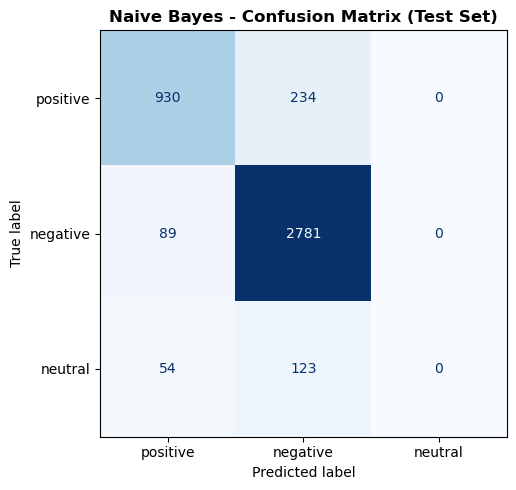

In [6]:
# Naive Bayes Test Evaluation
nb_test_pred = nb_model.predict(X_test)
nb_test_f1 = f1_score(y_test, nb_test_pred, average='weighted')
nb_test_acc = accuracy_score(y_test, nb_test_pred)

print("NAIVE BAYES - TEST RESULTS")
print(f"Weighted F1-score: {nb_test_f1:.4f}")
print(f"Accuracy:          {nb_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, nb_test_pred, labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative', 'neutral'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Naive Bayes - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_nb_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Naive Bayes Test Confirmation

Test set results confirm the validation finding, weighted F1 of 0.8608 
and accuracy of 0.8813, consistent with earlier results. The confusion 
matrix makes the neutral class failure starkly visible, the entire 
neutral prediction column shows zero across all three true sentiment 
classes, the model never once predicts neutral on the test set. All 
177 genuinely neutral reviews are misclassified, 123 as negative and 
54 as positive.

This confirms Naive Bayes, without class weighting, is structurally 
incapable of identifying the minority class given its current training 
distribution, regardless of how the data is split.

LOGISTIC REGRESSION (CLASS WEIGHTED) - TEST RESULTS
Weighted F1-score: 0.8644
Accuracy:          0.8554


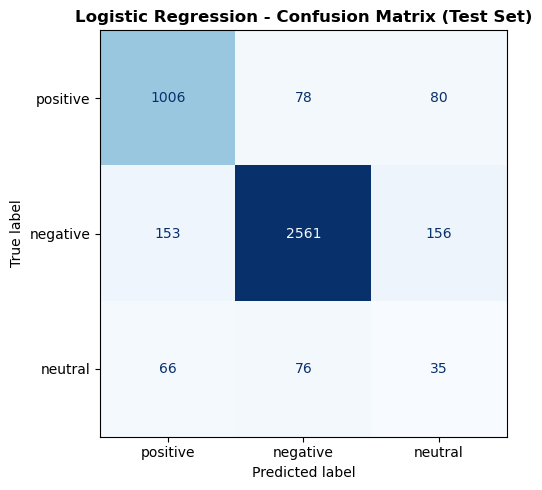

In [7]:
# Logistic Regression Test Evaluation
lr_test_pred = lr_model.predict(X_test)
lr_test_f1 = f1_score(y_test, lr_test_pred, average='weighted')
lr_test_acc = accuracy_score(y_test, lr_test_pred)

print("LOGISTIC REGRESSION (CLASS WEIGHTED) - TEST RESULTS")
print(f"Weighted F1-score: {lr_test_f1:.4f}")
print(f"Accuracy:          {lr_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_test_pred, labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative', 'neutral'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_lr_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Logistic Regression Test Confirmation

Test results confirm the validation finding, weighted F1 of 0.8644 
and accuracy of 0.8554, slightly outperforming Naive Bayes on weighted 
F1 despite lower accuracy. The confusion matrix shows the neutral 
class is no longer entirely ignored, 35 of 177 genuinely neutral 
reviews are correctly identified, alongside 76 misclassified as 
negative and 66 as positive.

This improvement comes at a measured cost to the negative class, which 
previously dominated predictions almost entirely, 153 negative reviews 
are now misclassified as positive and 156 as neutral. This trade-off 
is the expected and intended effect of class weighting, sacrificing 
some accuracy on the majority class to gain meaningful, if still 
limited, recognition of the minority class.

**Insight:** Neither classical model fully solves the neutral class 
problem, but Logistic Regression with class weighting represents a 
genuinely fairer model across all three sentiment categories, and 
should be considered the stronger baseline of the two for any 
production use case where correctly identifying neutral feedback 
matters to the business, despite its slightly lower raw accuracy.

## Save Models

In [8]:
with open(os.path.join(MODELS_PATH, 'production_naive_bayes_model.pkl'), 'wb') as f:
    pickle.dump(nb_model, f)

with open(os.path.join(MODELS_PATH, 'production_logistic_regression_model.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)

print("Models saved to models/ directory")
print("- production_naive_bayes_model.pkl")
print("- production_logistic_regression_model.pkl")

Models saved to models/ directory
- production_naive_bayes_model.pkl
- production_logistic_regression_model.pkl


## Summary

Naive Bayes achieved a weighted F1-score of 0.8608 and accuracy of 
0.8813 on the test set, but completely failed to identify any neutral 
reviews, predicting this class zero times across all test examples. 
Logistic Regression with balanced class weighting achieved a slightly 
higher weighted F1 of 0.8644, with a weighted ROC AUC of 0.9492 on 
validation confirming the underlying neutral signal is genuinely 
learnable, and correctly identified 35 of 177 neutral reviews on the 
test set, a meaningful improvement despite still limited recall.

These results, while imperfect, represent genuine model learning from 
authentic customer language, in clear contrast to memorisation of a 
constrained vocabulary. The persistent difficulty with the neutral 
class reflects the severe scarcity of examples, just 4.2% of the 
dataset, rather than a flaw in either modelling approach.

### Business Impact
Logistic Regression with class weighting is the stronger candidate of 
the two classical baselines for ShopEase Europe's production needs, 
correctly identifying moderate, lukewarm customer feedback matters for 
early intervention before dissatisfaction escalates into an outright 
negative review. However, neither model reliably solves this problem, 
and any deployment decision should weigh whether DistilBERT, evaluated 
in the next notebook, offers a meaningfully stronger solution before 
committing to a final production model. If gaps in neutral 
classification persist, sourcing additional neutral training examples 
should be considered a priority investment ahead of further model tuning.

Models saved to models/:
- production_naive_bayes_model.pkl
- production_logistic_regression_model.pkl